In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  # looks for a "src" sibling/parent of the notebook


[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
%reload_ext autoreload
%autoreload 2

from src.models.dpcn import DPCN
import torch
# pretend shallow feature: grayscale retinal preprocessed image batch
x = torch.randn(2, 1, 512, 512)  # (N=2, C=1, H=W=512)

dpcn = DPCN(
    in_ch=1,
    channels=None,     # keep 1 channel internally
    iters=11,           # number of iterations (tunable)
    beta=0.5,          # balance feeding vs linking
    aE=0.5,            # threshold decay
    V_E=1.0,           # threshold growth scale
    use_deformable=True,   # tries deformable conv; falls back if unavailable
    project_out=False
)

y = dpcn(x)
print("in/out:", x.shape, "->", y.shape)  # expect (2,1,512,512)


in/out: torch.Size([2, 1, 512, 512]) -> torch.Size([2, 1, 512, 512])


In [3]:
from src.data.prepare_dataset import build_all_train_pairs
from src.data.augmentations import get_train_augs, get_val_augs
from src.data.dataloader import make_loaders

# Build pairs from DRIVE/CHASEDB1/STARE
train_pairs_all = build_all_train_pairs(
    raw_root="../data/raw",
    datasets=("DRIVE", "CHASEDB1", "STARE")
)

# Build train/val loaders
train_loader, val_loader = make_loaders(
    train_pairs=train_pairs_all,
    image_size=512,
    batch_size=2,        # just 2 for easy visualization
    num_workers=0,
    seed=1337,
    strict_fov=True,
    augs_train=get_train_augs(512),
    augs_val=get_val_augs(512),
)


In shape: torch.Size([2, 1, 512, 512])
Out shape: torch.Size([2, 128, 512, 512])


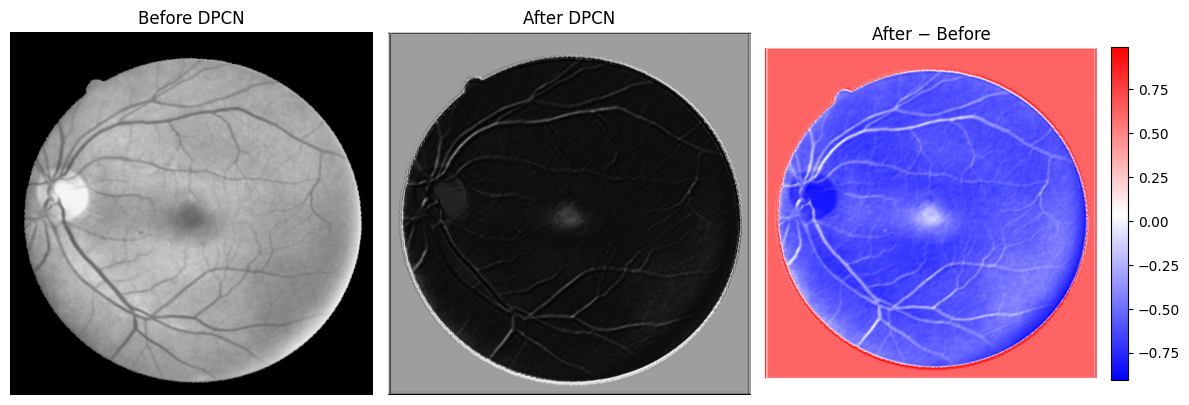

Mean abs change: 0.580075 | Max abs change: 0.992652


In [76]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from src.models.dpcn import DPCN

# 1) Grab a small batch from the train loader
batch = next(iter(train_loader))
x_in = batch["image"]  # [B,1,512,512]
print("In shape:", x_in.shape)

# 2) Build DPCN with the correct arg names
dpcn = DPCN(
    in_ch=1,
    channels=128,      
    iters=5,            # number of DPCN iterations
    beta=0.2,
    aE=5,
    V_E=3,
    use_deformable=False # will fallback to plain conv if not available
)

# 3) Forward pass
with torch.no_grad():
    x_out = dpcn(x_in)

print("Out shape:", x_out.shape)

# 4) Visualize first sample: before vs after + difference heatmap
img_in  = x_in[0,0].cpu().numpy()
img_out = x_out[0,0].cpu().numpy()
diff    = img_out - img_in

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img_in, cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Before DPCN"); axs[0].axis("off")

axs[1].imshow(img_out, cmap="gray", vmin=0, vmax=1)
axs[1].set_title("After DPCN"); axs[1].axis("off")

im = axs[2].imshow(diff, cmap="bwr")  # blue=decrease, red=increase
axs[2].set_title("After − Before"); axs[2].axis("off")
fig.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

# 5) Simple numeric summary
mae = float(np.abs(diff).mean())
mx  = float(np.abs(diff).max())
print(f"Mean abs change: {mae:.6f} | Max abs change: {mx:.6f}")
